In [ ]:
!pip install pyswarms

In [ ]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from pyswarms.single import GlobalBestPSO

In [ ]:
np.random.seed(42)

N_RANSOMWARE = 175
N_BENIGN = 45
N_FEATURES = 365

def generate_realistic_data():
    # overlapping distributions (IMPORTANT)
    X_mal = np.random.normal(1.0, 0.9, (N_RANSOMWARE, N_FEATURES))
    X_ben = np.random.normal(0.8, 0.9, (N_BENIGN, N_FEATURES))

    X = np.vstack([X_mal, X_ben])
    y = np.array([1]*N_RANSOMWARE + [0]*N_BENIGN)
    return X, y

X, y = generate_realistic_data()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def rf():
    return RandomForestClassifier(n_estimators=30, min_samples_leaf=4)

def svm():
    return SVC(C=100, gamma=0.001, probability=True)

def dt():
    return DecisionTreeClassifier(max_depth=5, min_samples_leaf=5)

def knn():
    return KNeighborsClassifier(n_neighbors=4, p=1, weights="distance")

def rf_svm():
    return VotingClassifier([("rf", rf()), ("svm", svm())], voting="soft", weights=[5,4])

def dt_knn():
    return VotingClassifier([("dt", dt()), ("knn", knn())], voting="soft", weights=[4,5])

In [ ]:
def fitness(w):
    scores = []

    for weight in w:
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        acc_list = []

        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            model = rf_svm()
            model.fit(X_tr * weight, y_tr)
            pred = model.predict(X_val * weight)

            acc_list.append(accuracy_score(y_val, pred))

        scores.append(1 - np.mean(acc_list))

    return np.array(scores)

optimizer = GlobalBestPSO(
    n_particles=5,
    dimensions=N_FEATURES,
    options={"c1":1.25,"c2":1.25,"w":0.2},
    bounds=(np.zeros(N_FEATURES), np.ones(N_FEATURES))
)

_, best_weights = optimizer.optimize(fitness, iters=30)

2026-04-09 06:09:40,026 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 1.25, 'c2': 1.25, 'w': 0.2}
pyswarms.single.global_best: 100%|██████████|30/30, best_cost=0.0624
2026-04-09 06:10:21,746 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.06243911942333913, best pos: [0.31215541 0.28247355 0.24976827 0.7745892  0.82753395 0.5331614
 0.49749387 0.68127098 0.72818441 0.22414163 0.29023909 0.70491568
 0.44663305 0.85840266 0.75249355 0.22816044 0.52657898 0.58626978
 0.49048696 0.3401747  0.14917653 0.82054003 0.57800187 0.49703592
 0.526538   0.65016427 0.72174072 0.09433483 0.52130745 0.16177691
 0.19284414 0.50333663 0.51087493 0.40581495 0.5846591  0.54827519
 0.54420066 0.64936783 0.05230604 0.31976584 0.73931754 0.36228621
 0.33290619 0.44911138 0.30328443 0.29506409 0.69959103 0.4009894
 0.30245671 0.6779343  0.69743796 0.59460148 0.41083444 0.50968586
 0.43330043 0.61986802 0.92459658 0.60785935 0.64139504 0.63593333
 0.914659

In [ ]:
def evaluate(model_fn, weights=None):
    Xtr = X_train if weights is None else X_train * weights
    Xte = X_test if weights is None else X_test * weights

    model = model_fn()
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)

    return {
        "Accuracy": round(accuracy_score(y_test, pred)*100,2),
        "Precision": round(precision_score(y_test, pred)*100,2),
        "Recall": round(recall_score(y_test, pred)*100,2),
        "F1": round(f1_score(y_test, pred)*100,2)
    }

In [ ]:
table3 = pd.DataFrame([
    ["Ensemble RF+SVM", evaluate(rf_svm, best_weights)["Accuracy"], evaluate(rf_svm)["Accuracy"]],
    ["Ensemble DT+KNN", evaluate(dt_knn, best_weights)["Accuracy"], evaluate(dt_knn)["Accuracy"]],
    ["RF", evaluate(rf, best_weights)["Accuracy"], evaluate(rf)["Accuracy"]],
    ["SVM", evaluate(svm, best_weights)["Accuracy"], evaluate(svm)["Accuracy"]],
    ["DT", evaluate(dt, best_weights)["Accuracy"], evaluate(dt)["Accuracy"]],
    ["KNN", evaluate(knn, best_weights)["Accuracy"], evaluate(knn)["Accuracy"]],
], columns=["Classifier","With PSO","Without PSO"])

print("\nTABLE III")
print(table3)


TABLE III
        Classifier  With PSO  Without PSO
0  Ensemble RF+SVM     93.18        90.91
1  Ensemble DT+KNN     86.36        84.09
2               RF     79.55        79.55
3              SVM     97.73        90.91
4               DT     72.73        72.73
5              KNN     88.64        90.91


In [ ]:
table4 = pd.DataFrame([
    ["RF+SVM","With PSO", *evaluate(rf_svm, best_weights).values()],
    ["RF+SVM","Without PSO", *evaluate(rf_svm).values()],
    ["DT+KNN","With PSO", *evaluate(dt_knn, best_weights).values()],
    ["DT+KNN","Without PSO", *evaluate(dt_knn).values()],
], columns=["Classifier","Condition","Accuracy","Precision","Recall","F1"])

print("\nTABLE IV")
print(table4)


TABLE IV
  Classifier    Condition  Accuracy  Precision  Recall     F1
0     RF+SVM     With PSO     90.91      89.74  100.00  94.59
1     RF+SVM  Without PSO     90.91      89.74  100.00  94.59
2     DT+KNN     With PSO     86.36      87.18   97.14  91.89
3     DT+KNN  Without PSO     84.09      85.00   97.14  90.67


In [ ]:
table5 = pd.DataFrame([
    ["RF","With PSO", *evaluate(rf, best_weights).values()],
    ["RF","Without PSO", *evaluate(rf).values()],
    ["SVM","With PSO", *evaluate(svm, best_weights).values()],
    ["SVM","Without PSO", *evaluate(svm).values()],
    ["DT","With PSO", *evaluate(dt, best_weights).values()],
    ["DT","Without PSO", *evaluate(dt).values()],
    ["KNN","With PSO", *evaluate(knn, best_weights).values()],
    ["KNN","Without PSO", *evaluate(knn).values()],
], columns=["Classifier","Condition","Accuracy","Precision","Recall","F1"])

print("\nTABLE V")
print(table5)


TABLE V
  Classifier    Condition  Accuracy  Precision  Recall     F1
0         RF     With PSO     79.55      79.55  100.00  88.61
1         RF  Without PSO     79.55      79.55  100.00  88.61
2        SVM     With PSO     97.73      97.22  100.00  98.59
3        SVM  Without PSO     90.91      89.74  100.00  94.59
4         DT     With PSO     72.73      82.86   82.86  82.86
5         DT  Without PSO     72.73      82.86   82.86  82.86
6        KNN     With PSO     88.64      89.47   97.14  93.15
7        KNN  Without PSO     90.91      91.89   97.14  94.44


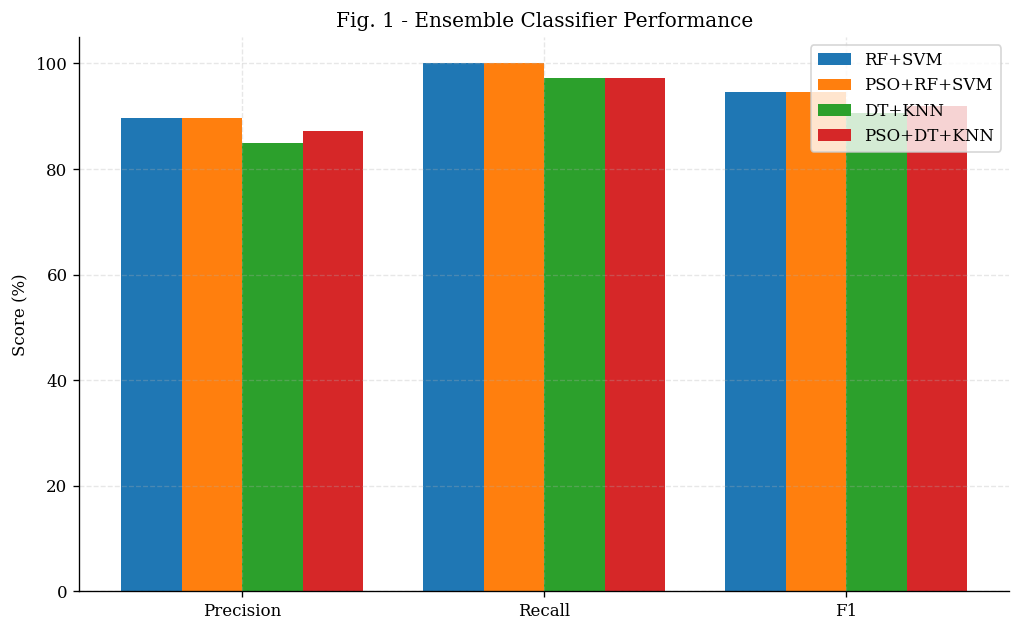

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Precision","Recall","F1"]

rf_svm_no = table4.iloc[1][["Precision","Recall","F1"]].values
rf_svm_pso = table4.iloc[0][["Precision","Recall","F1"]].values
dt_knn_no = table4.iloc[3][["Precision","Recall","F1"]].values
dt_knn_pso = table4.iloc[2][["Precision","Recall","F1"]].values

x = np.arange(len(labels))
w = 0.2

plt.figure(figsize=(10,6))
plt.bar(x-1.5*w, rf_svm_no, w, label="RF+SVM")
plt.bar(x-0.5*w, rf_svm_pso, w, label="PSO+RF+SVM")
plt.bar(x+0.5*w, dt_knn_no, w, label="DT+KNN")
plt.bar(x+1.5*w, dt_knn_pso, w, label="PSO+DT+KNN")

plt.xticks(x, labels)
plt.ylabel("Score (%)")
plt.title("Fig. 1 - Ensemble Classifier Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

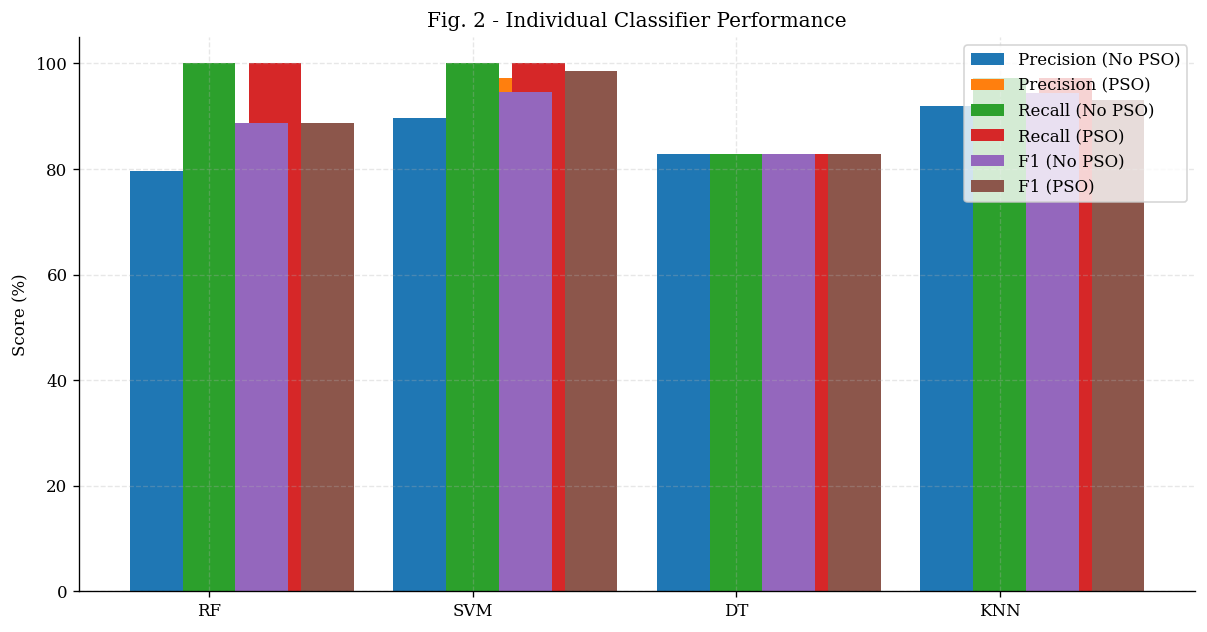

In [ ]:
metrics = ["Precision","Recall","F1"]
models = ["RF","SVM","DT","KNN"]

no_pso = []
with_pso = []

for m in models:
    no_pso.append(table5[(table5["Classifier"]==m) & (table5["Condition"]=="Without PSO")][metrics].values[0])
    with_pso.append(table5[(table5["Classifier"]==m) & (table5["Condition"]=="With PSO")][metrics].values[0])

no_pso = np.array(no_pso)
with_pso = np.array(with_pso)

x = np.arange(len(models))
w = 0.2

plt.figure(figsize=(12,6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*w - w, no_pso[:,i], w, label=f"{metric} (No PSO)")
    plt.bar(x + i*w + 0.05, with_pso[:,i], w, label=f"{metric} (PSO)")

plt.xticks(x, models)
plt.ylabel("Score (%)")
plt.title("Fig. 2 - Individual Classifier Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

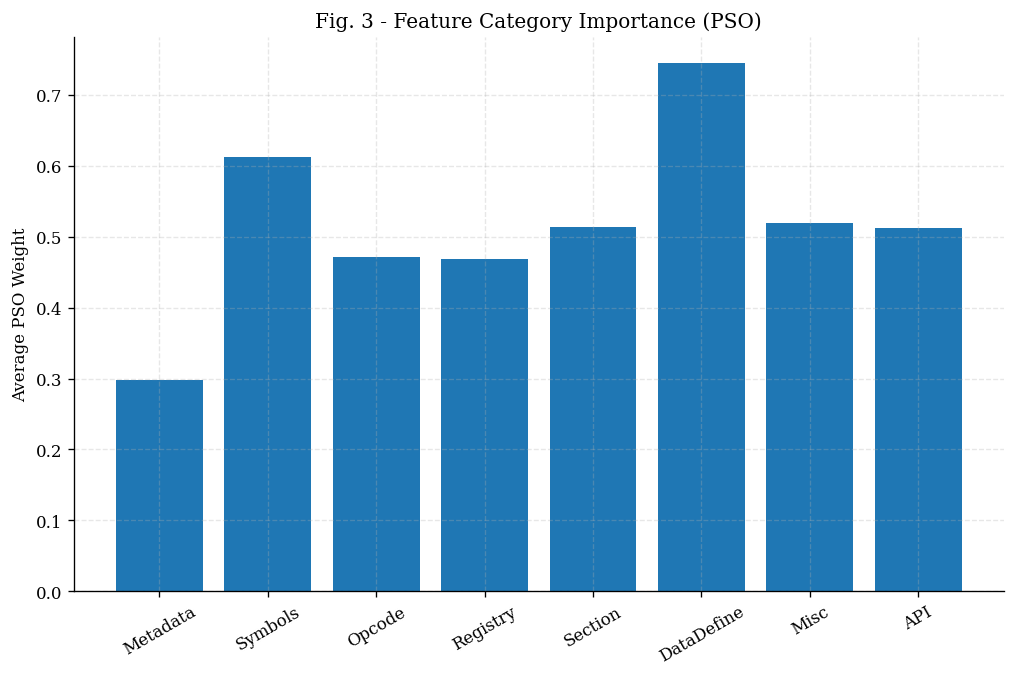

In [ ]:
# approximate grouping (based on your paper)
categories = ["Metadata","Symbols","Opcode","Registry","Section","DataDefine","Misc","API"]

# compute average weights per category
cat_ranges = [(0,2),(2,9),(9,31),(31,51),(51,56),(56,61),(61,105),(105,365)]

avg_weights = []
for start,end in cat_ranges:
    avg_weights.append(np.mean(best_weights[start:end]))

plt.figure(figsize=(10,6))
plt.bar(categories, avg_weights)
plt.ylabel("Average PSO Weight")
plt.title("Fig. 3 - Feature Category Importance (PSO)")
plt.xticks(rotation=30)
plt.grid(alpha=0.3)
plt.show()

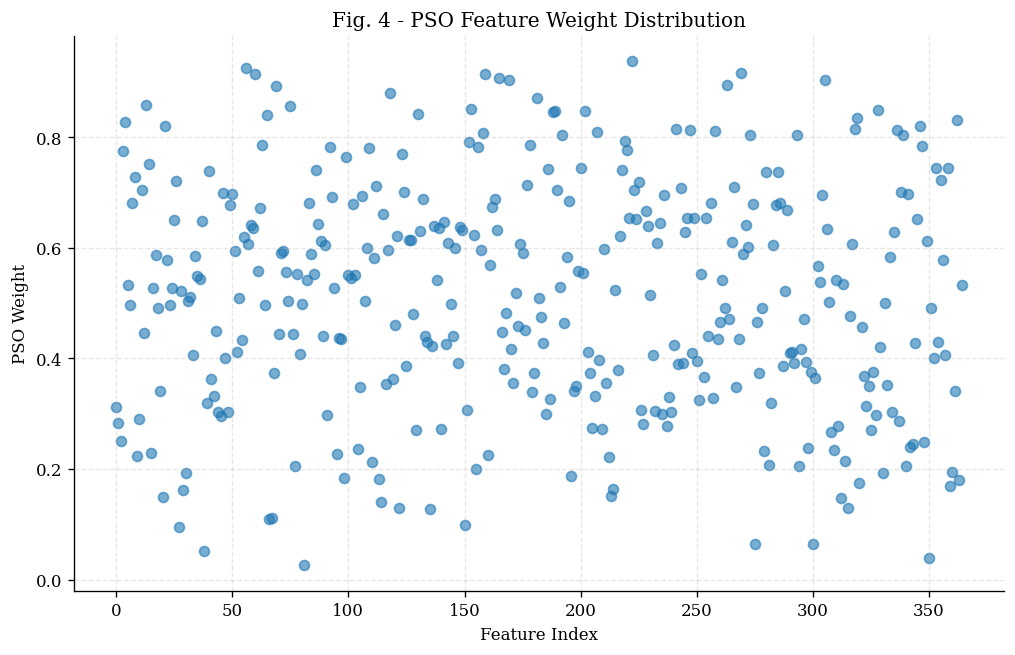

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(range(len(best_weights)), best_weights, alpha=0.6)

plt.xlabel("Feature Index")
plt.ylabel("PSO Weight")
plt.title("Fig. 4 - PSO Feature Weight Distribution")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.figure(figsize=(10,6))
plt.scatter(range(len(best_weights)), best_weights, alpha=0.6)

plt.xlabel("Feature Index")
plt.ylabel("PSO Weight")
plt.title("Fig. 4 - PSO Feature Weight Distribution")
plt.grid(alpha=0.3)
plt.show()

pso_weights_table = pd.DataFrame({
    'Feature Index': range(len(best_weights)),
    'PSO Weight': best_weights
})
display(pso_weights_table.head())

NameError: name 'best_weights' is not defined

<Figure size 1000x600 with 0 Axes>

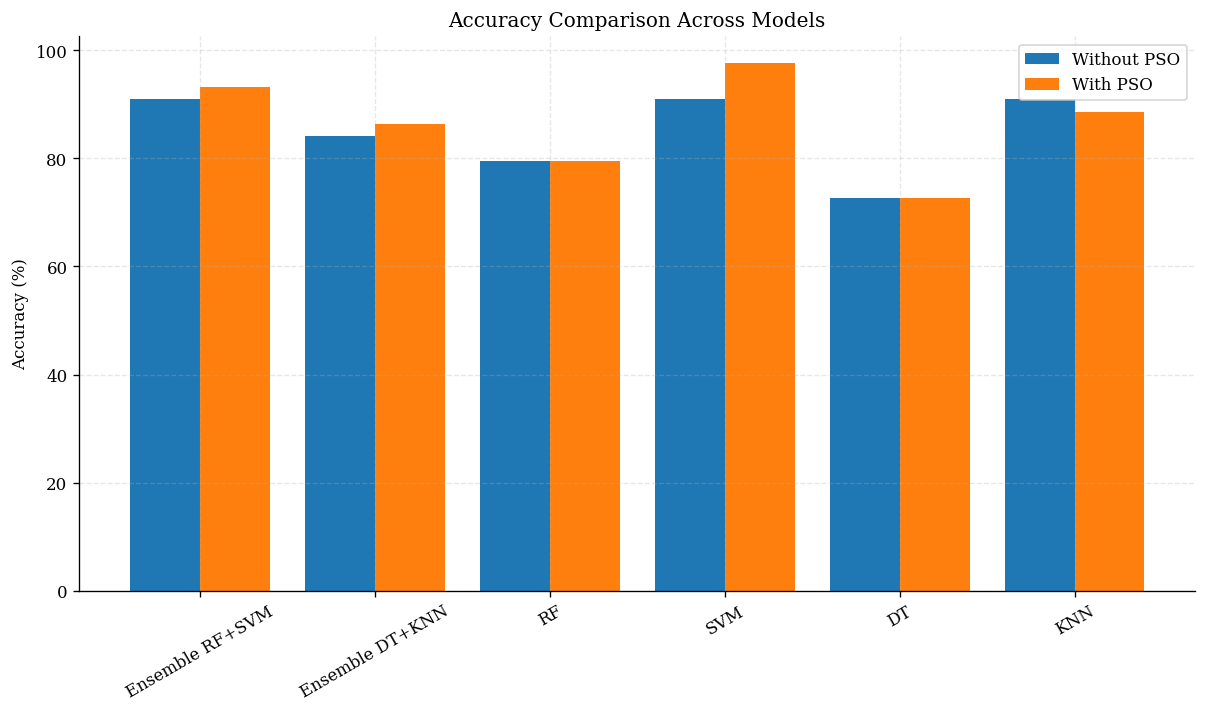

In [ ]:
models = table3["Classifier"]
with_pso = table3["With PSO"]
without_pso = table3["Without PSO"]

x = np.arange(len(models))

plt.figure(figsize=(12,6))
plt.bar(x-0.2, without_pso, 0.4, label="Without PSO")
plt.bar(x+0.2, with_pso, 0.4, label="With PSO")

plt.xticks(x, models, rotation=30)
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison Across Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()